In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/grapevine-leaves-image-dataset/Grapevine_Leaves_Image_Dataset/Grapevine_Leaves_Image_Dataset_Citation_Request.txt
/kaggle/input/grapevine-leaves-image-dataset/Grapevine_Leaves_Image_Dataset/Buzgulu/Buzgulu (20).png
/kaggle/input/grapevine-leaves-image-dataset/Grapevine_Leaves_Image_Dataset/Buzgulu/Buzgulu (16).png
/kaggle/input/grapevine-leaves-image-dataset/Grapevine_Leaves_Image_Dataset/Buzgulu/Buzgulu (79).png
/kaggle/input/grapevine-leaves-image-dataset/Grapevine_Leaves_Image_Dataset/Buzgulu/Buzgulu (55).png
/kaggle/input/grapevine-leaves-image-dataset/Grapevine_Leaves_Image_Dataset/Buzgulu/Buzgulu (53).png
/kaggle/input/grapevine-leaves-image-dataset/Grapevine_Leaves_Image_Dataset/Buzgulu/Buzgulu (23).png
/kaggle/input/grapevine-leaves-image-dataset/Grapevine_Leaves_Image_Dataset/Buzgulu/Buzgulu (42).png
/kaggle/input/grapevine-leaves-image-dataset/Grapevine_Leaves_Image_Dataset/Buzgulu/Buzgulu (72).png
/kaggle/input/grapevine-leaves-image-dataset/Grapevine_Leaves_Im

In [2]:
from torchvision import datasets,transforms
from torch.utils.data import DataLoader, random_split
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time
import torchvision.models as models
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Load Data

Applied data augmentation techniques such as random horizontal flipping, slight rotation, and color jittering to improve generalization

In [4]:
image_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2,contrast=0.2),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

In [5]:
dataset_path = "/kaggle/input/grapevine-leaves-image-dataset/Grapevine_Leaves_Image_Dataset"

dataset = datasets.ImageFolder(
    root = dataset_path,
    transform = image_transform
)
len(dataset)

500

Below are the classes the images belong to

In [6]:
dataset.classes

['Ak', 'Ala_Idris', 'Buzgulu', 'Dimnit', 'Nazli']

In [7]:
num_classes = len(dataset.classes)
num_classes

5

## Split Data

In [8]:
train_size = int(0.75*len(dataset))
val_size = len(dataset) - train_size

train_size,val_size

(375, 125)

In [9]:
train_dataset, val_dataset = random_split(dataset,[train_size,val_size]) 

In [10]:
train_loader = DataLoader(train_dataset,batch_size=16,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=16,shuffle=True)

## Visualize Data

In [11]:
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([16, 3, 224, 224])
torch.Size([16])


In [12]:
val = 2

In [13]:
print(labels[val])
print(dataset.classes[val])

tensor(4)
Buzgulu


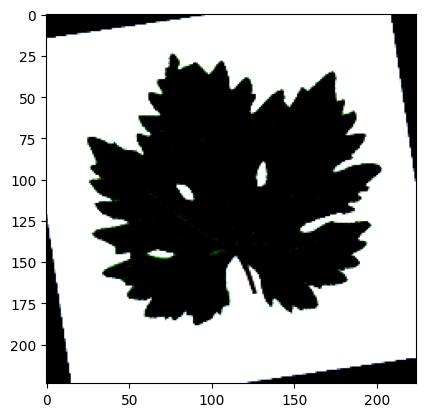

In [14]:
plt.imshow(images[val].permute(1,2,0))
plt.show()

## Model 1 : CNN

In [17]:
class GrapevineLeavesClassifierCNN(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=3,out_channels=16, kernel_size=3,stride=1,padding=1), #(16,224,224)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0), #(16, 112,112)
            
            nn.Conv2d(in_channels=16,out_channels=32, kernel_size=3,stride=1,padding=1), #(32,112,112)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0), #(32,56,56)

            nn.Conv2d(in_channels=32,out_channels=64, kernel_size=3,stride=1,padding=1), #(64,56,56)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0), #(64,28,28)

            nn.Flatten(),
            nn.Linear(64*28*28,512),
            nn.ReLU(),
            nn.Linear(512,num_classes)
        )

    def forward(self,x):
        x=self.network(x)
        return x

In [18]:
model = GrapevineLeavesClassifierCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.0001)

In [15]:
def train_model(model,criterion,optimizer,epochs=5):
    start = time.time()
    
    for epoch in range(epochs):
        #Training
        model.train()
        running_loss=0.0
        
        for batch_num,(images,labels) in enumerate(train_loader):
            images,labels = images.to(device),labels.to(device)

            #Zero the parameter gradients
            optimizer.zero_grad()
            
            #Forward Pass
            outputs = model(images)
            loss = criterion(outputs,labels)

            #Backward Pass | Optimization
            loss.backward()
            optimizer.step()

            if batch_num % 10 == 0:
                print(f"Batch: {batch_num+1}, Epoch: {epoch+1}, Loss: {loss.item():0.2f}")
            
            running_loss += loss.item() * images.size(0)
            
        epoch_loss = running_loss/len(train_loader.dataset)
        print(f"Epoch [{epoch+1}/{epochs}], Avg Loss: {epoch_loss:.4f}")

        #Validation
        model.eval()
        correct=0
        total=0
        all_labels = []
        all_predictions = []

        with torch.no_grad():
            for images, labels in val_loader:
                images,lables = images.to(device),labels.to(device)

                outputs = model(images)
                _, predicted = torch.max(outputs.data,1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())
            print(f"**Validation Accuracy: {100 * correct / total:0.2f}%**")

    end = time.time()
    print(f"Execution time: {end-start} seconds")

    return all_labels, all_predictions

In [90]:
all_labels, all_predictions = train_model(model,criterion,optimizer,epochs=5)

Batch: 1, Epoch: 1, Loss: 1.63
Batch: 11, Epoch: 1, Loss: 1.79
Batch: 21, Epoch: 1, Loss: 1.62
Epoch [1/5], Avg Loss: 1.6495
**Validation Accuracy: 18.40%**
Batch: 1, Epoch: 2, Loss: 1.53
Batch: 11, Epoch: 2, Loss: 1.66
Batch: 21, Epoch: 2, Loss: 1.65
Epoch [2/5], Avg Loss: 1.5990
**Validation Accuracy: 30.40%**
Batch: 1, Epoch: 3, Loss: 1.61
Batch: 11, Epoch: 3, Loss: 1.51
Batch: 21, Epoch: 3, Loss: 1.54
Epoch [3/5], Avg Loss: 1.5824
**Validation Accuracy: 18.40%**
Batch: 1, Epoch: 4, Loss: 1.53
Batch: 11, Epoch: 4, Loss: 1.54
Batch: 21, Epoch: 4, Loss: 1.50
Epoch [4/5], Avg Loss: 1.5600
**Validation Accuracy: 28.00%**
Batch: 1, Epoch: 5, Loss: 1.52
Batch: 11, Epoch: 5, Loss: 1.55
Batch: 21, Epoch: 5, Loss: 1.60
Epoch [5/5], Avg Loss: 1.5293
**Validation Accuracy: 27.20%**
Execution time: 122.61922335624695 seconds


##### Model 1: CNN achived a validation accuray of 27.2%

## Model 2: Transfer Learning with MobileNet

In [31]:
model = models.mobilenet_v3_small(weights='DEFAULT')
model.classifier[3].in_features

1024

In [35]:
class GrapevineLeavesClassifierMobileNet(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.model = models.mobilenet_v3_small(weights='DEFAULT')

        #Freeze all previous layers
        for param in self.model.parameters():
           param.requires_grad=False 
        
        in_features = self.model.classifier[3].in_features
        
        self.model.classifier = nn.Sequential(
            nn.Linear(in_features=576, out_features=1024, bias=True),
            nn.Hardswish(),
            nn.Dropout(0.5),
            nn.Linear(in_features,num_classes)
        )

    def forward(self,x):
        return self.model(x)

In [39]:
model = GrapevineLeavesClassifierMobileNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p:p.requires_grad,model.parameters()),lr=0.001)

In [40]:
all_labels, all_predictions = train_model(model,criterion,optimizer,epochs=5)

Batch: 1, Epoch: 1, Loss: 1.64
Batch: 11, Epoch: 1, Loss: 1.51
Batch: 21, Epoch: 1, Loss: 1.11
Epoch [1/5], Avg Loss: 1.4611
**Validation Accuracy: 19.20%**
Batch: 1, Epoch: 2, Loss: 1.20
Batch: 11, Epoch: 2, Loss: 1.09
Batch: 21, Epoch: 2, Loss: 0.75
Epoch [2/5], Avg Loss: 0.9791
**Validation Accuracy: 28.80%**
Batch: 1, Epoch: 3, Loss: 0.68
Batch: 11, Epoch: 3, Loss: 0.94
Batch: 21, Epoch: 3, Loss: 0.95
Epoch [3/5], Avg Loss: 0.8913
**Validation Accuracy: 29.60%**
Batch: 1, Epoch: 4, Loss: 0.80
Batch: 11, Epoch: 4, Loss: 0.76
Batch: 21, Epoch: 4, Loss: 0.73
Epoch [4/5], Avg Loss: 0.7749
**Validation Accuracy: 24.80%**
Batch: 1, Epoch: 5, Loss: 0.69
Batch: 11, Epoch: 5, Loss: 0.69
Batch: 21, Epoch: 5, Loss: 0.56
Epoch [5/5], Avg Loss: 0.8798
**Validation Accuracy: 31.20%**
Execution time: 62.49929404258728 seconds


##### Model 2: Transfer Learning with MobileNet achived a validation accuray of 31.2%

## Model 3: Transfer Learning with ResNet

In [16]:
class GrapevineLeavesClassifierResNet(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.model = models.resnet50(weights='DEFAULT')

        #Freeze all layers except final fully connecte layer (layer 4)
        for param in self.model.parameters():
           param.requires_grad=False 

        #Unfreeze final fully connecte layer (layer 4)
        for param in self.model.layer4.parameters():
           param.requires_grad=True 
        
        self.model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(self.model.fc.in_features,num_classes)
        )

    def forward(self,x):
        return self.model(x)

In [17]:
model = GrapevineLeavesClassifierResNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p:p.requires_grad,model.parameters()),lr=0.0001)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 168MB/s]


In [18]:
all_labels, all_predictions = train_model(model,criterion,optimizer,epochs=5)

Batch: 1, Epoch: 1, Loss: 1.61
Batch: 11, Epoch: 1, Loss: 1.55
Batch: 21, Epoch: 1, Loss: 1.41
Epoch [1/5], Avg Loss: 1.5428
**Validation Accuracy: 62.40%**
Batch: 1, Epoch: 2, Loss: 1.31
Batch: 11, Epoch: 2, Loss: 1.26
Batch: 21, Epoch: 2, Loss: 1.16
Epoch [2/5], Avg Loss: 1.2070
**Validation Accuracy: 78.40%**
Batch: 1, Epoch: 3, Loss: 0.79
Batch: 11, Epoch: 3, Loss: 0.78
Batch: 21, Epoch: 3, Loss: 0.53
Epoch [3/5], Avg Loss: 0.7130
**Validation Accuracy: 84.00%**
Batch: 1, Epoch: 4, Loss: 0.42
Batch: 11, Epoch: 4, Loss: 0.29
Batch: 21, Epoch: 4, Loss: 0.23
Epoch [4/5], Avg Loss: 0.3716
**Validation Accuracy: 92.00%**
Batch: 1, Epoch: 5, Loss: 0.14
Batch: 11, Epoch: 5, Loss: 0.26
Batch: 21, Epoch: 5, Loss: 0.25
Epoch [5/5], Avg Loss: 0.2247
**Validation Accuracy: 94.40%**
Execution time: 471.88985681533813 seconds


##### Model 3 Transfer Learning with ResNet has achived a validation accuray of 94.4%, which is so far the best among all models

## Model 4: CNN feature extraction using ResNet + SVM

In [23]:
# Remove the classifier (last 2 layers)
feature_extractor = nn.Sequential(*list(model.model.children())[:-2]).to(device)

def extract_features_labels(dataloader):
    features = []
    labels = []
    
    feature_extractor.eval()
    with torch.no_grad():
        for images, lbls in dataloader:
            images = images.to(device)
            outputs = feature_extractor(images)
            outputs = outputs.view(outputs.size(0), -1)  # Flatten features
            features.extend(outputs.cpu().numpy())
            labels.extend(lbls.numpy())
    
    return np.array(features), np.array(labels)

X_train, y_train = extract_features_labels(train_loader)
X_val, y_val = extract_features_labels(val_loader)

In [24]:
# Train SVM
svm = SVC(kernel='rbf', C=1.0)
svm.fit(X_train, y_train)

# Evaluate
y_pred = svm.predict(X_val)

print("SVM Validation Accuracy:", accuracy_score(y_val, y_pred) * 100)
print("\nClassification Report:\n", classification_report(y_val, y_pred))

SVM Validation Accuracy: 96.8

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       0.96      1.00      0.98        22
           2       0.89      0.96      0.92        25
           3       1.00      0.97      0.98        29
           4       1.00      0.93      0.96        29

    accuracy                           0.97       125
   macro avg       0.97      0.97      0.97       125
weighted avg       0.97      0.97      0.97       125



##### Model 4 (CNN feature extraction using ResNet + SVM with RBF kernel) achieved a validation accuracy of **96.8%**, outperforming all previous models, including the fine-tuned ResNet model, and demonstrating the effectiveness of combining deep feature extraction with traditional machine learning classifiers.


#### Below is a quick comparison of the first 20 predicted labels versus their corresponding ground truth labels:

In [29]:
print(f"Predictions: {y_pred[:20]}")
print(f"Ture values: {y_val[:20]}")

Predictions: [3 0 0 0 4 3 2 3 3 4 3 4 0 0 4 1 3 4 3 1]
Ture values: [3 0 0 0 4 3 2 3 3 4 3 4 0 0 4 1 3 4 3 1]


##### As shown above, the predictions closely match the true labels, indicating that the SVM classifier is performing well on this validation set.